# ARC-MolFormer: Adaptive Retention & Correction for Continual Molecular Property Prediction

> **Paper Reference**: Adaptive Retention & Correction: Test-Time Training for Continual Learning (ICLR 2025)  
> **Novel Application**: Molecular toxicity prediction using MolFormer backbone with ARC test-time adaptation

---

## Abstract

Continual learning for molecular property prediction faces catastrophic forgetting when models are sequentially trained on different toxicity datasets. This work adapts the **ARC (Adaptive Retention & Correction)** framework from the image classification domain to molecular property prediction using the **MolFormer** pretrained transformer. ARC operates entirely at test time — requiring no replay buffer, no retraining, and no ground-truth labels — making it uniquely suited to privacy-sensitive and memory-constrained drug discovery pipelines.

**Sequential Task Setup:**
- Task 1 → Tox21 (12 toxicity endpoints)
- Task 2 → ClinTox (2 clinical toxicity labels: FDA_APPROVED, CT_TOX)
- Task 3 → SIDER (27 side-effect categories)

**Key Contributions:**
1. First application of ARC to molecular property prediction
2. OTD-guided routing mechanism adapted for multi-label biochemical tasks
3. Entropy-minimization-based Adaptive Retention for classifier head re-balancing
4. Task-based Softmax Score correction for misclassified past-task molecules
5. **Pure CSV-based data loading — no DeepChem dependency required**

---

## Table of Contents
1. [Environment Setup & Dependencies](#1.-Environment-Setup-&-Dependencies)
2. [Imports & Configuration](#2.-Imports-&-Configuration)
3. [Dataset Loading & Preprocessing](#3.-Dataset-Loading-&-Preprocessing)
4. [Model Architecture: ArcMolFormer](#4.-Model-Architecture:-ArcMolFormer)
5. [Sequential Continual Training](#5.-Sequential-Continual-Training)
6. [OTD: Out-of-Task Detection](#6.-OTD:-Out-of-Task-Detection)
7. [ARC: Adaptive Retention & Correction](#7.-ARC:-Adaptive-Retention-&-Correction)
8. [Evaluation Metrics](#8.-Evaluation-Metrics)
9. [Full Pipeline Execution](#9.-Full-Pipeline-Execution)
10. [Results Visualization & Analysis](#10.-Results-Visualization-&-Analysis)


---
## 1. Environment Setup & Dependencies


In [4]:
# Install required packages
# Run this cell once. Restart kernel after installation if needed.
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

packages = [
    'torch>=2.0.0',
    'transformers>=4.35.0',
    'scikit-learn>=1.3.0',
    'numpy>=1.24.0',
    'matplotlib>=3.7.0',
    'pandas>=2.0.0',
    'rdkit',
    'einops',                   # required by MolFormer
    'rotary-embedding-torch',   # required by MolFormer
]

for pkg in packages:
    try:
        install(pkg)
        print(f'  ✓ {pkg}')
    except Exception as e:
        print(f'  ✗ {pkg}: {e}')

print('\nInstallation complete. Restart kernel if this is the first run.')


  ✓ torch>=2.0.0


  ✓ transformers>=4.35.0


  ✓ scikit-learn>=1.3.0


  ✓ numpy>=1.24.0


  ✓ matplotlib>=3.7.0


  ✓ pandas>=2.0.0


  ✓ rdkit


  ✓ einops


  ✓ rotary-embedding-torch

Installation complete. Restart kernel if this is the first run.


---
## 2. Imports & Configuration


In [5]:
# ─── Standard Library ────────────────────────────────────────────────────────
import os
import sys
import copy
import warnings
import logging
from typing import Dict, List, Tuple, Optional
from pathlib import Path

warnings.filterwarnings('ignore')
logging.getLogger('transformers').setLevel(logging.ERROR)

# ─── Scientific Computing ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ─── PyTorch ─────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

# ─── HuggingFace Transformers ─────────────────────────────────────────────────
from transformers import AutoTokenizer, AutoModel

# ─── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

# ─── Device Configuration ────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


Device: cuda
PyTorch: 2.2.2+cu121
GPU: Tesla V100S-PCIE-32GB
Memory: 34.1 GB


In [6]:
# ─── Hyperparameter Configuration ────────────────────────────────────────────

CFG = {
    # Task setup  (Task 1 → Tox21 | Task 2 → ClinTox | Task 3 → SIDER)
    'tasks':      ['tox21', 'clintox', 'sider'],
    'num_labels': {'tox21': 12, 'clintox': 2, 'sider': 27},

    # ── CSV paths ─────────────────────────────────────────────────────────────
    # Place your CSV files at these paths, OR keep the URLs to auto-download.
    # Each CSV must have a 'smiles' column + one column per label.
    #
    # Tox21   columns : smiles, NR-AR, NR-AR-LBD, NR-AhR, NR-Aromatase,
    #                   NR-ER, NR-ER-LBD, NR-PPAR-gamma, SR-ARE, SR-ATAD5,
    #                   SR-HSE, SR-MMP, SR-p53
    # ClinTox columns : smiles, FDA_APPROVED, CT_TOX
    # SIDER   columns : smiles, Hepatobiliary disorders, Metabolism & nutrition
    #                   disorders, ... (27 side-effect columns)
    'csv_paths': {
        'tox21':   '/home/student/MolFormer/vidhi/tox21.csv',
        'clintox': '/home/student/MolFormer/vidhi/clintox.csv',
        'sider':   '/home/student/MolFormer/vidhi/sider.csv',
    },

    

    # Column name for SMILES in each CSV
    'smiles_col': {
        'tox21':   'smiles',
        'clintox': 'smiles',
        'sider':   'smiles',
    },

    # MolFormer
    'molformer_name': 'ibm/MolFormer-XL-both-10pct',
    'max_seq_length': 128,
    'hidden_dim':     768,
    'freeze_backbone': True,

    # Classifier head
    'head_hidden': 256,
    'dropout':     0.1,

    # Training
    'epochs':     10,           # Increase to 10-15 for publication runs
    'batch_size': 32,
    'train_lr':   1e-3,
    'grad_clip':  1.0,

    # ARC / OTD
    'epsilon':        0.55,     # Confidence threshold (ε)
    'arc_lr':         1e-4,    # LR for one-step retention update
    'lambda_entropy': 1.0,     # Weight for entropy minimization

    # Data split ratios (applied to each CSV)
    'frac_train': 0.70,
    'frac_valid': 0.15,
    'frac_test':  0.15,

    # Reproducibility
    'seed': 42,
}

# Set global random seeds
torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(CFG['seed'])

print('Configuration loaded:')
for k, v in CFG.items():
    print(f'  {k}: {v}')


Configuration loaded:
  tasks: ['tox21', 'clintox', 'sider']
  num_labels: {'tox21': 12, 'clintox': 2, 'sider': 27}
  csv_paths: {'tox21': '/home/student/MolFormer/vidhi/tox21.csv', 'clintox': '/home/student/MolFormer/vidhi/clintox.csv', 'sider': '/home/student/MolFormer/vidhi/sider.csv'}
  smiles_col: {'tox21': 'smiles', 'clintox': 'smiles', 'sider': 'smiles'}
  molformer_name: ibm/MolFormer-XL-both-10pct
  max_seq_length: 128
  hidden_dim: 768
  freeze_backbone: True
  head_hidden: 256
  dropout: 0.1
  epochs: 10
  batch_size: 32
  train_lr: 0.001
  grad_clip: 1.0
  epsilon: 0.55
  arc_lr: 0.0001
  lambda_entropy: 1.0
  frac_train: 0.7
  frac_valid: 0.15
  frac_test: 0.15
  seed: 42


---
## 3. Dataset Loading & Preprocessing

All three datasets are loaded from **CSV files** — no DeepChem required.

| Dataset | Task Type | Labels | Compounds | CSV Columns |
|---------|-----------|--------|-----------|-------------|
| **Tox21** | Nuclear receptor / stress response toxicity | 12 | ~7,831 | `smiles` + 12 label cols |
| **ClinTox** | FDA approval & clinical trial toxicity | 2 | ~1,478 | `smiles`, `FDA_APPROVED`, `CT_TOX` |
| **SIDER** | Drug side-effect categories | 27 | ~1,427 | `smiles` + 27 side-effect cols |

### CSV Format Expected

```
smiles,FDA_APPROVED,CT_TOX
CC(=O)Oc1ccccc1C(=O)O,1,0
CN1C=NC2=C1C(=O)N(C(=O)N2C)C,1,0
...
```

### Data Pipeline

```
CSV file
   │
   ▼
pd.read_csv()
   │
   ▼
Drop rows where smiles is NaN
   │
   ▼
Stratified train/val/test split (70/15/15)
   │
   ▼
MolecularDataset  →  DataLoader
```

> **Auto-download**: If a CSV file is not found at the configured path,
> the loader will automatically download it from the S3 URL defined in `CFG['csv_urls']`.


In [7]:
# ─── CSV Dataset Loader (No DeepChem) ────────────────────────────────────────

from typing import List, Tuple, Dict   # ✅ FIX
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

# ── Label columns for each dataset ────────────────────────────────────────────
DATASET_LABEL_COLS = {
    'tox21': [
        'NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase',
        'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma',
        'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53'
    ],
    'clintox': ['FDA_APPROVED', 'CT_TOX'],
    'sider': [
        'Hepatobiliary disorders',
        'Metabolism and nutrition disorders',
        'Product issues',
        'Eye disorders',
        'Investigations',
        'Musculoskeletal and connective tissue disorders',
        'Gastrointestinal disorders',
        'Social circumstances',
        'Immune system disorders',
        'Reproductive system and breast disorders',
        'Neoplasms benign, malignant and unspecified (incl cysts and polyps)',
        'General disorders and administration site conditions',
        'Endocrine disorders',
        'Surgical and medical procedures',
        'Vascular disorders',
        'Blood and lymphatic system disorders',
        'Skin and subcutaneous tissue disorders',
        'Congenital, familial and genetic disorders',
        'Infections and infestations',
        'Respiratory, thoracic and mediastinal disorders',
        'Psychiatric disorders',
        'Renal and urinary disorders',
        'Pregnancy, puerperium and perinatal conditions',
        'Ear and labyrinth disorders',
        'Cardiac disorders',
        'Nervous system disorders',
        'Injury, poisoning and procedural complications'
    ],
}


def load_csv_dataset(name: str) -> Tuple[List[str], np.ndarray, List[str]]:
    """
    Load a toxicity dataset from CSV.
    """
    csv_path = CFG['csv_paths'][name]

    # ── Only check existence (URL download removed) ───────────────────────
    if not Path(csv_path).exists():
        raise FileNotFoundError(f'CSV not found at {csv_path}')

    # ── Read CSV ──────────────────────────────────────────────────────────
    df = pd.read_csv(csv_path)
    print(f'  Read {csv_path}: {len(df)} rows, {len(df.columns)} columns')
    print(f'  Columns: {list(df.columns)}')

    # ── Detect SMILES column ──────────────────────────────────────────────
    smiles_col = CFG['smiles_col'].get(name, 'smiles')
    col_lower  = {c.lower(): c for c in df.columns}

    if smiles_col not in df.columns:
        for candidate in ['smiles', 'SMILES', 'Smiles', 'mol', 'structure']:
            if candidate.lower() in col_lower:
                smiles_col = col_lower[candidate.lower()]
                print(f'  Auto-detected SMILES column: {smiles_col!r}')
                break
        else:
            raise ValueError(
                f'Cannot find SMILES column in {name} CSV.\n'
                f'Available columns: {list(df.columns)}'
            )

    # ── Detect label columns ──────────────────────────────────────────────
    expected_cols = DATASET_LABEL_COLS.get(name, [])

    if expected_cols:
        label_cols = [c for c in expected_cols if c in df.columns]
        if not label_cols:
            raise ValueError(
                f'No expected label columns found in {name}'
            )
    else:
        label_cols = [c for c in df.columns if c != smiles_col
                      and pd.api.types.is_numeric_dtype(df[c])]

    print(f'  Using {len(label_cols)} label columns')

    # ── Drop bad SMILES ───────────────────────────────────────────────────
    df = df.dropna(subset=[smiles_col])
    df = df[df[smiles_col].str.strip() != '']

    # ── Extract ───────────────────────────────────────────────────────────
    smiles = df[smiles_col].tolist()
    labels = df[label_cols].values.astype(np.float32)

    print(f'  Final: {len(smiles)} × {len(label_cols)}')

    return smiles, labels, label_cols


def split_dataset(
    smiles: List[str],
    labels: np.ndarray,
    frac_train: float = 0.70,
    frac_valid: float = 0.15,
    seed: int = 42
) -> Tuple:

    n = len(smiles)

    idx = np.arange(n)
    rng = np.random.default_rng(seed)
    rng.shuffle(idx)

    n_train = int(n * frac_train)
    n_val   = int(n * frac_valid)

    train_idx = idx[:n_train]
    val_idx   = idx[n_train:n_train + n_val]
    test_idx  = idx[n_train + n_val:]

    smiles_arr = np.array(smiles)

    return (
        smiles_arr[train_idx].tolist(), labels[train_idx],
        smiles_arr[val_idx].tolist(),   labels[val_idx],
        smiles_arr[test_idx].tolist(),  labels[test_idx],
    )


class MolecularDataset(Dataset):

    def __init__(self, smiles_list, labels, tokenizer, max_length=128):
        self.smiles     = smiles_list
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        smi   = str(self.smiles[idx])
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        label = torch.nan_to_num(label, nan=0.0)

        encoding = self.tokenizer(
            smi,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels':         label
        }


def load_dataset_loaders(
    name: str,
    tokenizer,
    batch_size: int = 32,
    max_length: int = 128
):

    print(f'  Loading {name.upper()} from CSV...')

    smiles, labels, label_cols = load_csv_dataset(name)
    n_labels = len(label_cols)

    CFG['num_labels'][name] = n_labels

    train_smiles, train_y, val_smiles, val_y, test_smiles, test_y = split_dataset(
        smiles, labels,
        frac_train=CFG['frac_train'],
        frac_valid=CFG['frac_valid'],
        seed=CFG['seed']
    )

    train_y_clean = np.nan_to_num(train_y.copy(), nan=0.0)
    pos_count = train_y_clean.sum(axis=0) + 1e-6
    neg_count = (1.0 - np.clip(train_y_clean, 0, 1)).sum(axis=0) + 1e-6
    pos_weight = torch.tensor(neg_count / pos_count, dtype=torch.float32)
    pos_weight = torch.clamp(pos_weight, min=0.1, max=20.0)

    def make_loader(smi_list, lbl_array, shuffle):
        ds = MolecularDataset(
            smi_list,
            np.array(lbl_array, dtype=np.float32),
            tokenizer,
            max_length
        )
        return DataLoader(
            ds,
            batch_size=batch_size,
            shuffle=shuffle,
            num_workers=0
        )

    train_loader = make_loader(train_smiles, train_y, True)
    val_loader   = make_loader(val_smiles,   val_y, False)
    test_loader  = make_loader(test_smiles,  test_y, False)

    return train_loader, val_loader, test_loader, pos_weight, n_labels

---
## 4. Model Architecture: ArcMolFormer

```
SMILES Input
     │
     ▼
MolFormer Tokenizer
     │
     ▼
Pretrained MolFormer (Frozen Backbone)
     │
     ▼
Mean Pooling → h ∈ R^768
     │
   ┌─────────┬─────────┐
   ▼         ▼         ▼
Head_Tox21  Head_ClinTox  Head_SIDER
 (12)        (617)         (27)
```

Each head: `Linear(768→256) → GELU → Dropout(0.1) → Linear(256→num_labels)`


In [8]:
class ClassifierHead(nn.Module):
    """
    Task-specific classification head.

    Architecture: Linear(768→256) → GELU → Dropout → Linear(256→num_labels)
    """

    def __init__(self, input_dim: int, num_labels: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, CFG['head_hidden']),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(CFG['head_hidden'], num_labels)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class ArcMolFormer(nn.Module):
    """
    Multi-head MolFormer model for dataset-incremental continual learning.

    Backbone : ibm/MolFormer-XL-both-10pct (frozen during training)
    Heads    : one separate ClassifierHead per task

    Args:
        num_labels_per_task: dict mapping task_name → number of labels
        freeze_backbone:     whether to freeze MolFormer weights
    """

    MOLFORMER_NAME = 'ibm/MolFormer-XL-both-10pct'

    def __init__(self,
                 num_labels_per_task: Dict[str, int],
                 freeze_backbone: bool = True):
        super().__init__()

        print('Loading MolFormer backbone...')
        self.molformer = AutoModel.from_pretrained(
            self.MOLFORMER_NAME, trust_remote_code=True
        )

        if freeze_backbone:
            for param in self.molformer.parameters():
                param.requires_grad = False
            print('  Backbone frozen (requires_grad=False).')

        # Detect hidden dim from model config
        try:
            self.hidden_dim = self.molformer.config.hidden_size
        except AttributeError:
            self.hidden_dim = 768  # MolFormer default
        print(f'  Hidden dim: {self.hidden_dim}')

        # One head per task
        self.heads = nn.ModuleDict({
            task: ClassifierHead(self.hidden_dim, n_labels, CFG['dropout'])
            for task, n_labels in num_labels_per_task.items()
        })
        self.task_names = list(num_labels_per_task.keys())

        total_head_params = sum(
            sum(p.numel() for p in h.parameters())
            for h in self.heads.values()
        )
        print(f'  Total head parameters: {total_head_params:,}')

    def get_embedding(self,
                      input_ids: torch.Tensor,
                      attention_mask: torch.Tensor) -> torch.Tensor:
        """
        Extract molecular embedding via MolFormer + mean pooling.

        Args:
            input_ids:      [B, seq_len]
            attention_mask: [B, seq_len]

        Returns:
            embeddings: [B, hidden_dim]
        """
        with torch.no_grad():
            outputs = self.molformer(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        token_embeddings = outputs.last_hidden_state  # [B, seq, hidden]
        mask = attention_mask.unsqueeze(-1).float()    # [B, seq, 1]

        # Masked mean pooling
        sum_embeddings = (token_embeddings * mask).sum(dim=1)  # [B, hidden]
        sum_mask = mask.sum(dim=1).clamp(min=1e-9)             # [B, 1]
        return sum_embeddings / sum_mask                        # [B, hidden]

    def forward(self,
                input_ids: torch.Tensor,
                attention_mask: torch.Tensor,
                task_name: str) -> torch.Tensor:
        """
        Forward pass for a specific task.

        Returns:
            logits: [B, num_labels_for_task]
        """
        h = self.get_embedding(input_ids, attention_mask)
        return self.heads[task_name](h)

    def forward_all_heads(self,
                          input_ids: torch.Tensor,
                          attention_mask: torch.Tensor) -> Dict[str, torch.Tensor]:
        """
        Run all task heads in one forward pass.
        Used by OTD and Adaptive Correction.

        Returns:
            dict: {task_name: logits [B, num_labels]}
        """
        h = self.get_embedding(input_ids, attention_mask)
        return {task: self.heads[task](h) for task in self.task_names}

    def count_trainable_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


print('Model classes defined.')


Model classes defined.


---
## 5. Sequential Continual Training

Tasks are trained one at a time in fixed order: **Tox21 → ClinTox → SIDER**.

Only the current task's classifier head is updated. The MolFormer backbone remains frozen. Previous heads are preserved unchanged.

$$\mathcal{L}_{\text{train}} = \text{BCEWithLogitsLoss}(\hat{y}, y) \quad \text{(with class weights for imbalance)}$$


In [9]:
def evaluate_task_auroc(
    model: ArcMolFormer,
    loader: DataLoader,
    task_name: str,
    device: torch.device
) -> float:
    """
    Evaluate a task using mean AUROC across valid labels.

    Skips labels with only one class present (undefined AUROC).

    Returns:
        mean_auroc: float in [0, 1]
    """
    model.eval()
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labs = batch['labels'].numpy()

            logits = model(ids, mask, task_name)
            probs  = torch.sigmoid(logits).cpu().numpy()

            all_probs.append(probs)
            all_labels.append(labs)

    all_probs  = np.concatenate(all_probs,  axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    aurocs = []
    for col in range(all_labels.shape[1]):
        y_true = all_labels[:, col]
        y_pred = all_probs[:,  col]
        # Remove NaN entries
        valid  = ~np.isnan(y_true)
        y_true = y_true[valid]
        y_pred = y_pred[valid]
        if len(np.unique(y_true)) > 1:
            try:
                aurocs.append(roc_auc_score(y_true, y_pred))
            except ValueError:
                pass

    return float(np.mean(aurocs)) if aurocs else 0.5


def train_one_task(
    model: ArcMolFormer,
    train_loader: DataLoader,
    val_loader: DataLoader,
    task_name: str,
    pos_weight: torch.Tensor,
    device: torch.device,
    epochs: int = 5,
    lr: float = 1e-3
) -> Dict[str, List[float]]:
    """
    Train a single task's classifier head.

    ONLY the current task's head parameters are optimized.
    Backbone is always frozen. Previous heads are untouched.

    Args:
        model:        ArcMolFormer instance
        train_loader: DataLoader for current task
        val_loader:   Validation DataLoader
        task_name:    which head to train
        pos_weight:   per-label class weights [num_labels]
        device:       torch.device
        epochs:       training epochs
        lr:           learning rate

    Returns:
        history: dict with 'train_loss' and 'val_auroc' lists
    """
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight.to(device)
    )

    # Optimize ONLY this task's head
    optimizer = Adam(model.heads[task_name].parameters(), lr=lr)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr * 0.01)

    history = {'train_loss': [], 'val_auroc': []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        n_batches  = 0

        for batch in train_loader:
            ids    = batch['input_ids'].to(device)
            mask   = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            logits = model(ids, mask, task_name)
            loss   = criterion(logits, labels)
            loss.backward()

            # Gradient clipping for stability
            nn.utils.clip_grad_norm_(
                model.heads[task_name].parameters(),
                max_norm=CFG['grad_clip']
            )
            optimizer.step()

            total_loss += loss.item()
            n_batches  += 1

        scheduler.step()
        avg_loss  = total_loss / max(n_batches, 1)
        val_auroc = evaluate_task_auroc(model, val_loader, task_name, device)

        history['train_loss'].append(avg_loss)
        history['val_auroc'].append(val_auroc)

        print(f'    [Task={task_name.upper():8s}] Epoch {epoch+1:2d}/{epochs} '
              f'| Loss: {avg_loss:.4f} | Val AUROC: {val_auroc:.4f}')

    return history


print('Training utilities defined.')


Training utilities defined.


---
## 6. OTD: Out-of-Task Detection

OTD is the **routing brain** of ARC. It is a **pure decision mechanism** — no trainable parameters, no gradient updates. It inspects confidence scores across all task heads and routes each sample to the correct ARC action.

| Case | Condition | Action |
|------|-----------|--------|
| 1 | `best_task ≠ current_task` AND `past_conf > ε` | **Adaptive Retention** |
| 2 | `best_task == current_task` AND `current_conf < ε` | **Adaptive Correction** |
| 3 | `best_task == current_task` AND `current_conf ≥ ε` | **No action** |

**Confidence** = `max(sigmoid(logits_for_task))`


In [10]:
def otd_decision(
    logits_dict:  Dict[str, torch.Tensor],
    current_task: str,
    seen_tasks:   List[str],
    epsilon:      float = 0.55
) -> Tuple[str, str]:
    """
    Out-of-Task Detection: pure confidence-based routing.

    This function performs NO gradient operations and updates NO parameters.
    It only inspects per-head confidence and returns a routing decision.

    Implements the two assumptions from the ARC paper:
      - Assumption 1: high-confidence prediction into a past task class
        → sample likely belongs to that past task → trigger Retention
      - Assumption 2: low-confidence prediction into current task class
        → sample likely misclassified from a past task → trigger Correction

    Args:
        logits_dict:  {task_name: logits tensor [1, num_labels]}
        current_task: name of the task currently being evaluated
        seen_tasks:   all tasks observed so far (in order)
        epsilon:      confidence threshold ε (default 0.7)

    Returns:
        action:        'retention' | 'correction' | 'none'
        selected_task: task name relevant to the action
    """
    # ── Step 1: Compute max-sigmoid confidence per head ───────────────────
    confidences: Dict[str, float] = {}
    with torch.no_grad():
        for task in seen_tasks:
            if task in logits_dict:
                probs = torch.sigmoid(logits_dict[task])  # [1, num_labels]
                confidences[task] = probs.max().item()

    if not confidences:
        return 'none', current_task

    # ── Step 2: Identify best task and relevant confidence values ─────────
    best_task = max(confidences, key=confidences.get)
    current_conf = confidences.get(current_task, 0.0)
    print(f"current: {current_task}, best: {best_task}, conf: {confidences}")

    # Best past task (all tasks except current)
    past_tasks = [t for t in seen_tasks if t != current_task]
    if past_tasks:
        best_past_task = max(past_tasks, key=lambda t: confidences.get(t, 0.0))
        best_past_conf = confidences.get(best_past_task, 0.0)
    else:
        best_past_task = current_task
        best_past_conf = 0.0

    # ── Step 3: Apply OTD decision rules (paper: Assumptions 1 & 2) ──────

    # CASE 1 — Adaptive Retention
    # Model confidently predicts a past task → reinforce that head
    margin = best_past_conf - current_conf
    if best_task != current_task and best_past_conf > epsilon and margin > 0.1:
        return 'retention', best_past_task

    # CASE 2 — Adaptive Correction
    # Model predicts current task but with low confidence
    # → likely a past-task sample misclassified into current task
    if current_conf < epsilon and margin < 0.2:
        return 'correction', current_task
    # CASE 3 — No action
    # Confident, correct current-task prediction
    return 'none', current_task


# ── Unit test for OTD ─────────────────────────────────────────────────────────

def _test_otd():
    """Quick sanity check of OTD routing logic."""
    # Case 1: model confidently predicts past task
    logits = {
        'tox21':   torch.tensor([[2.5, -1.0, 0.5]]),   # high conf
        'clintox': torch.tensor([[-1.0, -2.0, -1.5]]), # low conf
        'sider':   torch.tensor([[-0.5, 0.1, -0.3]]),  # low conf
    }
    action, task = otd_decision(logits, 'sider', ['tox21', 'clintox', 'sider'], epsilon=0.7)
    assert action == 'retention' and task == 'tox21', f'Case 1 failed: {action}, {task}'

    # Case 2: current task predicted but low confidence
    logits2 = {
        'tox21':   torch.tensor([[-1.0, -2.0, -1.5]]),
        'clintox': torch.tensor([[-0.5, 0.1, -0.3]]),
        'sider':   torch.tensor([[0.3, -0.2, 0.1]]),   # max sigmoid ≈ 0.57
    }
    action2, task2 = otd_decision(logits2, 'sider', ['tox21', 'clintox', 'sider'], epsilon=0.7)
    assert action2 == 'correction', f'Case 2 failed: {action2}'

    # Case 3: confident current task
    logits3 = {
        'tox21':   torch.tensor([[-1.0, -2.0, -1.5]]),
        'sider':   torch.tensor([[2.5, 1.5, 2.0]]),    # high conf
    }
    action3, task3 = otd_decision(logits3, 'sider', ['tox21', 'sider'], epsilon=0.7)
    assert action3 == 'none', f'Case 3 failed: {action3}'

    print('OTD unit tests: ✓ All 3 cases passed.')




---
## 7. ARC: Adaptive Retention & Correction

### 7.1 Adaptive Retention
Triggered when OTD detects a **correctly classified past-task sample** (high confidence).

$$\mathcal{L} = \mathcal{L}_{\text{BCE}}(\hat{y}, \tilde{y}) + \lambda \cdot \mathcal{L}_{\text{EM}}$$

where $\tilde{y}$ is the pseudo-label (binarized sigmoid output) and $\mathcal{L}_{\text{EM}} = -\mathbb{E}[p \log p]$.

### 7.2 Adaptive Correction
Triggered when OTD detects a **past-task sample misclassified into the current task** (low confidence).

Rescores all heads and re-assigns the sample to the most confident task — **no gradient updates**.


In [12]:
class ARC:
    """
    Adaptive Retention & Correction — test-time adaptation for continual learning.

    Pipeline per sample:
        1. Forward all heads → logits_dict
        2. OTD inspects confidences → routes to action
        3. 'retention'  → 1-step head update (high-conf past task)
        4. 'correction' → reassign to best-match head (low-conf current task)
        5. 'none'       → standard prediction unchanged

    Backbone is ALWAYS frozen during ARC. Only classifier heads may update.
    """

    def __init__(self,
                 model:          ArcMolFormer,
                 seen_tasks:     List[str],
                 epsilon:        float = 0.55,
                 lr:             float = 1e-4,
                 lambda_entropy: float = 1.0):
        """
        Args:
            model:          ArcMolFormer instance
            seen_tasks:     list of task names seen so far
            epsilon:        OTD confidence threshold ε
            lr:             learning rate for 1-step retention update
            lambda_entropy: weight for entropy minimization in retention
        """
        self.model          = model
        self.seen_tasks     = seen_tasks
        self.epsilon        = epsilon
        self.lr             = lr
        self.lambda_entropy = lambda_entropy
        self.bce_loss       = nn.BCEWithLogitsLoss()

        # Tracking statistics
        self.stats = {'retention': 0, 'correction': 0, 'none': 0}

    def _entropy_loss(self, logits: torch.Tensor) -> torch.Tensor:
        """
        Entropy minimization loss: L_em = -(p * log(p + ε)).mean()

        Encourages the model to make confident predictions,
        counteracting noise introduced by pseudo-labeling.
        """
        p = torch.sigmoid(logits)
        return -(p * torch.log(p + 1e-8)).mean()

    def adaptive_retention(
        self,
        input_ids:      torch.Tensor,
        attention_mask: torch.Tensor,
        task_name:      str,
        device:         torch.device
    ) -> torch.Tensor:
        """
        Adaptive Retention: one-step classifier update on a high-confidence
        past-task sample using pseudo-labels + entropy minimization.

        Triggered by OTD Case 1:
          best_task ≠ current_task AND best_past_conf > ε

        Steps:
          1. Forward pass → logits
          2. Pseudo-label = binarize sigmoid(logits) > 0.5
          3. L = BCE(logits, pseudo_label) + λ * entropy(logits)
          4. One gradient step on head only
          5. Recompute logits after update

        Returns:
            updated logits [1, num_labels]
        """
        head = self.model.heads[task_name]
        optimizer = torch.optim.Adam(head.parameters(), lr=self.lr)

        self.model.train()
        optimizer.zero_grad()

        logits = self.model(input_ids, attention_mask, task_name)

        # Generate pseudo-labels (no ground truth available)
        with torch.no_grad():
            pseudo_label = (torch.sigmoid(logits) > 0.5).float()

        # Combined objective: BCE + Entropy Minimization
        l_bce = self.bce_loss(logits, pseudo_label)
        l_em  = self._entropy_loss(logits)
        loss  = l_bce + self.lambda_entropy * l_em

        loss.backward()
        optimizer.step()

        # Recompute prediction with updated weights
        self.model.eval()
        with torch.no_grad():
            updated_logits = self.model(input_ids, attention_mask, task_name)

        return updated_logits

    def adaptive_correction(
        self,
        input_ids:      torch.Tensor,
        attention_mask: torch.Tensor,
        device:         torch.device
    ) -> Tuple[str, torch.Tensor]:
        """
        Adaptive Correction: rescore all heads and reassign sample
        to the most confident task.

        Triggered by OTD Case 2:
          best_task == current_task AND current_conf < ε

        No gradient updates are performed. Training-free bias correction.

        Returns:
            best_task:   str — name of reassigned task
            best_logits: [1, num_labels] — logits from that task's head
        """
        self.model.eval()
        with torch.no_grad():
            all_logits = self.model.forward_all_heads(input_ids, attention_mask)

        # Score each seen task by max sigmoid confidence
        task_scores = {
            task: torch.sigmoid(all_logits[task]).max().item()
            for task in self.seen_tasks
            if task in all_logits
        }

        best_task   = max(task_scores, key=task_scores.get)
        best_logits = all_logits[best_task]

        return best_task, best_logits

    def predict(
        self,
        input_ids:      torch.Tensor,
        attention_mask: torch.Tensor,
        current_task:   str,
        device:         torch.device
    ) -> Tuple[torch.Tensor, str]:
        """
        Full ARC prediction for a single sample.

        Steps:
          1. Run all heads → logits_dict
          2. OTD decides routing (no parameter updates)
          3. Dispatch to Retention / Correction / None
          4. Return final sigmoid probabilities and task used

        Args:
            input_ids, attention_mask: tokenized SMILES [1, seq_len]
            current_task: task being evaluated
            device:       torch.device

        Returns:
            probs:     [1, num_labels] sigmoid probabilities
            task_used: which head produced final output
        """
        # Step 1: Get all logits for OTD inspection only
        self.model.eval()
        with torch.no_grad():
            logits_dict = self.model.forward_all_heads(input_ids, attention_mask)

        # Step 2: OTD routing — pure decision, no parameter changes
        action, selected_task = otd_decision(
            logits_dict  = logits_dict,
            current_task = current_task,
            seen_tasks   = self.seen_tasks,
            epsilon      = self.epsilon
        )
        self.stats[action] += 1

        # Step 3: Dispatch to correct ARC module
        if action == 'retention':
            updated_logits = self.adaptive_retention(
                input_ids, attention_mask, selected_task, device
            )
            probs     = torch.sigmoid(updated_logits)
            task_used = selected_task

        elif action == 'correction':
            best_task, best_logits = self.adaptive_correction(
                input_ids, attention_mask, device
            )
            probs     = torch.sigmoid(best_logits)
            task_used = best_task

        else:  # 'none'
            probs     = torch.sigmoid(logits_dict[current_task])
            task_used = current_task

        return probs, task_used

    def get_routing_stats(self) -> Dict[str, float]:
        """Return OTD routing statistics as percentages."""
        total = sum(self.stats.values()) or 1
        return {k: v / total * 100 for k, v in self.stats.items()}

    def reset_stats(self):
        """Reset routing statistics."""
        self.stats = {'retention': 0, 'correction': 0, 'none': 0}


print('ARC class defined.')


ARC class defined.


---
## 8. Evaluation Metrics

We use the standard continual learning evaluation protocol:

**Accuracy Matrix** $R \in \mathbb{R}^{T \times T}$:
$$R[t][i] = \text{AUROC of task } T_i \text{ after training through task } T_t$$

**Average Accuracy:**
$$A_B = \frac{1}{T} \sum_{i=1}^{T} R[T][i]$$

**Forgetting:**
$$\mathcal{F} = \frac{1}{T-1} \sum_{i=1}^{T-1} \left( \max_{t \leq T} R[t][i] - R[T][i] \right)$$


In [13]:
def evaluate_with_arc(arc, loader, task_name, device):
    arc.model.eval()
    all_probs  = []
    all_labels = []

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].cpu().numpy()

        batch_probs = []

        for i in range(input_ids.size(0)):
            ids_i = input_ids[i:i+1]
            mask_i = attention_mask[i:i+1]

            # ARC decision
            _ = arc.predict(ids_i, mask_i, task_name, device)

            # 🔥 Always use correct head
            logits_dict = arc.model.forward_all_heads(ids_i, mask_i)
            probs = torch.sigmoid(logits_dict[task_name])

            batch_probs.append(probs.cpu().detach().numpy())

        # ✅ FIX: inside loop
        all_probs.append(np.concatenate(batch_probs, axis=0))
        all_labels.append(labels)

    all_probs  = np.concatenate(all_probs,  axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    # AUROC calculation
    aurocs = []
    for col in range(all_labels.shape[1]):
        y_true = all_labels[:, col]
        y_pred = all_probs[:, col]

        valid = ~np.isnan(y_true)
        y_true = y_true[valid]
        y_pred = y_pred[valid]

        if len(np.unique(y_true)) > 1:
            try:
                aurocs.append(roc_auc_score(y_true, y_pred))
            except:
                pass

    return float(np.mean(aurocs)) if aurocs else 0.5

---
## 9. Full Pipeline Execution

This section runs the complete experiment:
1. Load tokenizer and datasets
2. Build model
3. Sequential training (Task 1 → 2 → 3)
4. Baseline evaluation (no ARC)
5. ARC test-time evaluation
6. Compute and print continual learning metrics


In [14]:
# ─── Step 1: Load Tokenizer ───────────────────────────────────────────────────
print('='*60)
print('STEP 1: Loading MolFormer Tokenizer')
print('='*60)

tokenizer = AutoTokenizer.from_pretrained(
    CFG['molformer_name'],
    trust_remote_code=True
)
print(f'Tokenizer: {CFG["molformer_name"]}')
print(f'Vocab size: {tokenizer.vocab_size}')


STEP 1: Loading MolFormer Tokenizer
Tokenizer: ibm/MolFormer-XL-both-10pct
Vocab size: 2362


In [15]:
# ─── Step 2: Load All Datasets ──────────────────────────────────────────────
print('='*60)
print('STEP 2: Loading Datasets (CSV-based)')
print('='*60)

data = {}
for task in CFG['tasks']:
    print(f'\nLoading {task.upper()}...')
    train_loader, val_loader, test_loader, pos_weight, n_labels = \
        load_dataset_loaders(
            task,
            tokenizer,
            batch_size=CFG['batch_size'],
            max_length=CFG['max_seq_length']
        )
    data[task] = {
        'train':      train_loader,
        'val':        val_loader,
        'test':       test_loader,
        'pos_weight': pos_weight,
        'n_labels':   n_labels
    }
    print(f'  ✓ {task}: {n_labels} labels | '
          f'train={len(train_loader.dataset)}, '
          f'val={len(val_loader.dataset)}, '
          f'test={len(test_loader.dataset)}')

# Sync num_labels in CFG after dynamic detection
print('\nFinal label counts:')
for task in CFG['tasks']:
    print(f'  {task:10s}: {CFG["num_labels"][task]} labels')

print('\nAll datasets loaded successfully.')


STEP 2: Loading Datasets (CSV-based)

Loading TOX21...
  Loading TOX21 from CSV...
  Read /home/student/MolFormer/vidhi/tox21.csv: 7831 rows, 15 columns
  Columns: ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53', 'mol_id', 'SMILES', 'Label']
  Auto-detected SMILES column: 'SMILES'
  Using 12 label columns
  Final: 7831 × 12
  ✓ tox21: 12 labels | train=5481, val=1174, test=1176

Loading CLINTOX...
  Loading CLINTOX from CSV...
  Read /home/student/MolFormer/vidhi/clintox.csv: 1478 rows, 3 columns
  Columns: ['SMILES', 'FDA_APPROVED', 'Label']
  Auto-detected SMILES column: 'SMILES'
  Using 1 label columns
  Final: 1478 × 1
  ✓ clintox: 1 labels | train=1034, val=221, test=223

Loading SIDER...
  Loading SIDER from CSV...
  Read /home/student/MolFormer/vidhi/sider.csv: 1427 rows, 28 columns
  Columns: ['SMILES', 'Label', 'Metabolism and nutrition disorders', 'Product issues', 'Eye disorders', 'Inv

In [16]:
# ─── Step 3: Build Model ──────────────────────────────────────────────────────
print('='*60)
print('STEP 3: Building ArcMolFormer Model')
print('='*60)

model = ArcMolFormer(
    num_labels_per_task=CFG['num_labels'],
    freeze_backbone=CFG['freeze_backbone']
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = model.count_trainable_params()
print(f'\nTotal parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'Frozen:               {total_params - trainable_params:,}')


STEP 3: Building ArcMolFormer Model
Loading MolFormer backbone...
  Backbone frozen (requires_grad=False).
  Hidden dim: 768
  Total head parameters: 600,615

Total parameters:     44,975,655
Trainable parameters: 600,615
Frozen:               44,375,040


In [19]:
print(model)

ArcMolFormer(
  (molformer): MolformerModel(
    (embeddings): MolformerEmbeddings(
      (word_embeddings): Embedding(2362, 768, padding_idx=2)
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (encoder): MolformerEncoder(
      (layer): ModuleList(
        (0-11): 12 x MolformerLayer(
          (attention): MolformerAttention(
            (self): MolformerSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (rotary_embeddings): MolformerRotaryEmbedding()
              (feature_map): MolformerFeatureMap(
                (kernel): ReLU()
              )
            )
            (output): MolformerSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
              (dr

In [22]:
# ─── Step 4: Sequential Continual Training ────────────────────────────────────
print('='*60)
print('STEP 4: Sequential Continual Training')
print('  Order: Tox21 → ClinTox → SIDER')
print('='*60)

T = len(CFG['tasks'])

# R_base[t][i] = AUROC of task i after training up to task t
R_base = np.zeros((T, T))

training_histories = {}

for t_idx, task in enumerate(CFG['tasks']):
    print(f'\n{"─"*50}')
    print(f'  Task {t_idx+1}/{T}: {task.upper()}')
    print(f'{"─"*50}')

    history = train_one_task(
        model       = model,
        train_loader= data[task]['train'],
        val_loader  = data[task]['val'],
        task_name   = task,
        pos_weight  = data[task]['pos_weight'],
        device      = DEVICE,
        epochs      = CFG['epochs'],
        lr          = CFG['train_lr']
    )
    training_histories[task] = history

    # Evaluate all seen tasks after training task t (BASELINE — no ARC)
    print(f'\n  Baseline evaluation after Task {t_idx+1}:')
    for i_idx in range(t_idx + 1):
        past_task = CFG['tasks'][i_idx]
        auroc = evaluate_task_auroc(model, data[past_task]['test'], past_task, DEVICE)
        R_base[t_idx][i_idx] = auroc
        print(f'    {past_task.upper():10s}: AUROC = {auroc:.4f}')

print(f'\n{"="*60}')
print('Sequential training complete.')


STEP 4: Sequential Continual Training
  Order: Tox21 → ClinTox → SIDER

──────────────────────────────────────────────────
  Task 1/3: TOX21
──────────────────────────────────────────────────
    [Task=TOX21   ] Epoch  1/10 | Loss: 1.0513 | Val AUROC: 0.7939
    [Task=TOX21   ] Epoch  2/10 | Loss: 0.9385 | Val AUROC: 0.8025
    [Task=TOX21   ] Epoch  3/10 | Loss: 0.8799 | Val AUROC: 0.8121
    [Task=TOX21   ] Epoch  4/10 | Loss: 0.8309 | Val AUROC: 0.8266
    [Task=TOX21   ] Epoch  5/10 | Loss: 0.7782 | Val AUROC: 0.8314
    [Task=TOX21   ] Epoch  6/10 | Loss: 0.7449 | Val AUROC: 0.8233
    [Task=TOX21   ] Epoch  7/10 | Loss: 0.7097 | Val AUROC: 0.8231
    [Task=TOX21   ] Epoch  8/10 | Loss: 0.6787 | Val AUROC: 0.8245
    [Task=TOX21   ] Epoch  9/10 | Loss: 0.6657 | Val AUROC: 0.8304
    [Task=TOX21   ] Epoch 10/10 | Loss: 0.6550 | Val AUROC: 0.8265

  Baseline evaluation after Task 1:
    TOX21     : AUROC = 0.8004

──────────────────────────────────────────────────
  Task 2/3: CLINTO

In [23]:
# ─── Step 5: ARC Test-Time Evaluation ────────────────────────────────────────
print('='*60)
print('STEP 5: ARC Test-Time Evaluation')
print('='*60)

R_arc = np.zeros((T, T))
arc_routing_stats = {}  # track OTD routing distributions

for t_idx, task in enumerate(CFG['tasks']):
    print(f'\n  After Task {t_idx+1} ({task.upper()}) — ARC evaluation:')

    # Build ARC with all tasks seen up to this point
    arc = ARC(
        model       = model,
        seen_tasks  = CFG['tasks'][:t_idx + 1],
        epsilon     = CFG['epsilon'],
        lr          = CFG['arc_lr'],
        lambda_entropy = CFG['lambda_entropy']
    )

    for i_idx in range(t_idx + 1):
        past_task = CFG['tasks'][i_idx]
        arc.reset_stats()

        auroc = evaluate_with_arc(
            arc       = arc,
            loader    = data[past_task]['test'],
            task_name = past_task,
            device    = DEVICE
        )
        R_arc[t_idx][i_idx] = auroc
        routing = arc.get_routing_stats()

        print(f'    {past_task.upper():10s}: AUROC = {auroc:.4f} '
              f'| Routing → Ret: {routing["retention"]:.1f}% '
              f'Cor: {routing["correction"]:.1f}% '
              f'None: {routing["none"]:.1f}%')

        arc_routing_stats[f'T{t_idx+1}_{past_task}'] = routing

print(f'\n{"="*60}')
print('ARC evaluation complete.')


STEP 5: ARC Test-Time Evaluation

  After Task 1 (TOX21) — ARC evaluation:
current: tox21, best: tox21, conf: {'tox21': 0.7711054086685181}
current: tox21, best: tox21, conf: {'tox21': 0.6317641735076904}
current: tox21, best: tox21, conf: {'tox21': 0.7314189672470093}
current: tox21, best: tox21, conf: {'tox21': 0.20870521664619446}
current: tox21, best: tox21, conf: {'tox21': 0.5905072093009949}
current: tox21, best: tox21, conf: {'tox21': 0.6334699392318726}
current: tox21, best: tox21, conf: {'tox21': 0.3801027536392212}
current: tox21, best: tox21, conf: {'tox21': 0.49689221382141113}
current: tox21, best: tox21, conf: {'tox21': 0.34080836176872253}
current: tox21, best: tox21, conf: {'tox21': 0.8005695343017578}
current: tox21, best: tox21, conf: {'tox21': 0.5178905725479126}
current: tox21, best: tox21, conf: {'tox21': 0.9289721250534058}
current: tox21, best: tox21, conf: {'tox21': 0.6071558594703674}
current: tox21, best: tox21, conf: {'tox21': 0.4770566523075104}
current: tox

In [24]:
def compute_cl_metrics(R):
    """
    Compute Continual Learning metrics:
    - Average Accuracy
    - Forgetting

    Args:
        R: accuracy matrix (T x T)

    Returns:
        avg_acc: average final accuracy
        forgetting: average forgetting
    """
    T = R.shape[0]

    # Final accuracy (last row)
    final_acc = R[T-1, :]

    # Average Accuracy
    avg_acc = final_acc.mean()

    # Forgetting
    forgetting_list = []
    for i in range(T):
        # max accuracy of task i before final step
        max_acc = R[:T, i].max()
        final = R[T-1, i]
        forgetting_list.append(max_acc - final)

    forgetting = np.mean(forgetting_list)

    return avg_acc, forgetting

In [25]:
# ─── Step 6: Compute & Report Final Metrics ───────────────────────────────────
print('='*60)
print('STEP 6: Final Continual Learning Metrics')
print('='*60)

avg_acc_base, forgetting_base = compute_cl_metrics(R_base)
avg_acc_arc,  forgetting_arc  = compute_cl_metrics(R_arc)

delta_acc = avg_acc_arc - avg_acc_base
delta_fgt = forgetting_base - forgetting_arc  # positive = ARC reduces forgetting

print(f'\n  {"Method":<25} {"Avg AUROC":>12} {"Forgetting":>12}')
print(f'  {"─"*50}')
print(f'  {"Baseline (no ARC)":<25} {avg_acc_base:>12.4f} {forgetting_base:>12.4f}')
print(f'  {"ARC (ours)":<25} {avg_acc_arc:>12.4f} {forgetting_arc:>12.4f}')
print(f'  {"─"*50}')
sign_acc = '+' if delta_acc >= 0 else ''
sign_fgt = '+' if delta_fgt >= 0 else ''
print(f'  {"Δ (ARC − Baseline)":<25} {sign_acc}{delta_acc:>11.4f} {sign_fgt}{delta_fgt:>11.4f} ↓')

print(f'\n  Accuracy Matrix (Baseline):')
header = f'  {"":12s}' + ''.join([f'{t.upper():>12s}' for t in CFG['tasks']])
print(header)
for t_idx in range(T):
    row = f'  After T{t_idx+1:1d}   '
    for i_idx in range(T):
        val = R_base[t_idx][i_idx]
        row += f'{val:>12.4f}' if val > 0 else f'{"——":>12s}'
    print(row)

print(f'\n  Accuracy Matrix (ARC):')
print(header)
for t_idx in range(T):
    row = f'  After T{t_idx+1:1d}   '
    for i_idx in range(T):
        val = R_arc[t_idx][i_idx]
        row += f'{val:>12.4f}' if val > 0 else f'{"——":>12s}'
    print(row)


STEP 6: Final Continual Learning Metrics

  Method                       Avg AUROC   Forgetting
  ──────────────────────────────────────────────────
  Baseline (no ARC)               0.8192       0.0009
  ARC (ours)                      0.7624       0.0131
  ──────────────────────────────────────────────────
  Δ (ARC − Baseline)            -0.0568     -0.0122 ↓

  Accuracy Matrix (Baseline):
                     TOX21     CLINTOX       SIDER
  After T1         0.8004          ——          ——
  After T2         0.8033      0.9798          ——
  After T3         0.8099      0.9771      0.6705

  Accuracy Matrix (ARC):
                     TOX21     CLINTOX       SIDER
  After T1         0.8025          ——          ——
  After T2         0.8094      0.8454          ——
  After T3         0.8038      0.8117      0.6716


---
## 10. Results Visualization & Analysis


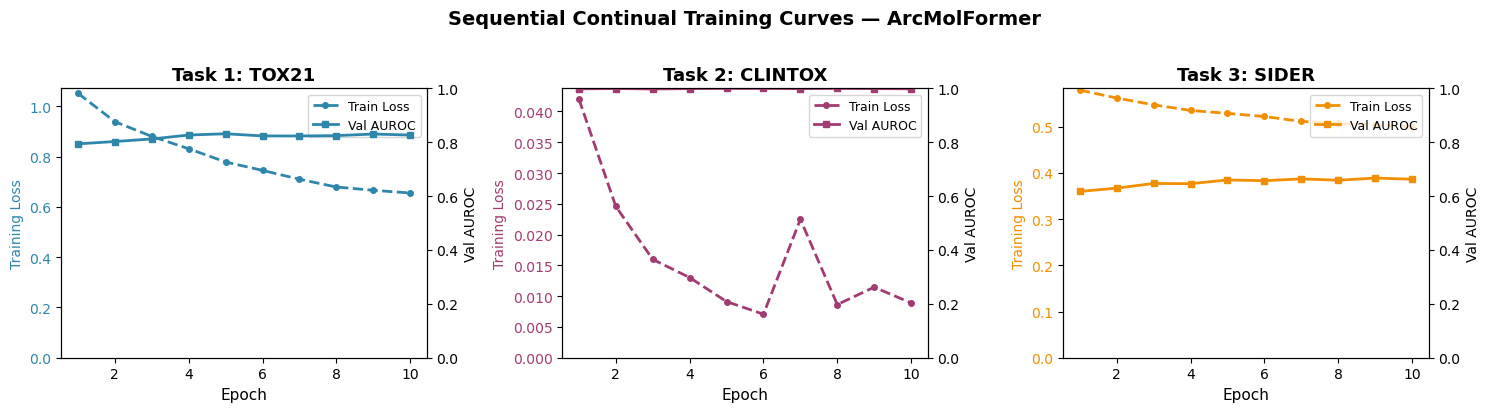

Figure 1 saved: fig1_training_curves.png


In [26]:
# ─── Figure 1: Training Curves ────────────────────────────────────────────────
fig, axes = plt.subplots(1, T, figsize=(5 * T, 4), sharey=False)
if T == 1:
    axes = [axes]

colors = ['#2E86AB', '#A23B72', '#F18F01']

for idx, (task, ax) in enumerate(zip(CFG['tasks'], axes)):
    hist = training_histories[task]
    ep   = range(1, len(hist['train_loss']) + 1)

    ax2 = ax.twinx()
    ax.plot(ep, hist['train_loss'], color=colors[idx], linewidth=2,
            linestyle='--', label='Train Loss', marker='o', markersize=4)
    ax2.plot(ep, hist['val_auroc'], color=colors[idx], linewidth=2,
             label='Val AUROC', marker='s', markersize=4)

    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Training Loss', color=colors[idx], fontsize=10)
    ax2.set_ylabel('Val AUROC', fontsize=10)
    ax.set_title(f'Task {idx+1}: {task.upper()}', fontsize=13, fontweight='bold')
    ax.tick_params(axis='y', labelcolor=colors[idx])
    ax.set_ylim(bottom=0)
    ax2.set_ylim(0, 1)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

fig.suptitle('Sequential Continual Training Curves — ArcMolFormer',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved: fig1_training_curves.png')


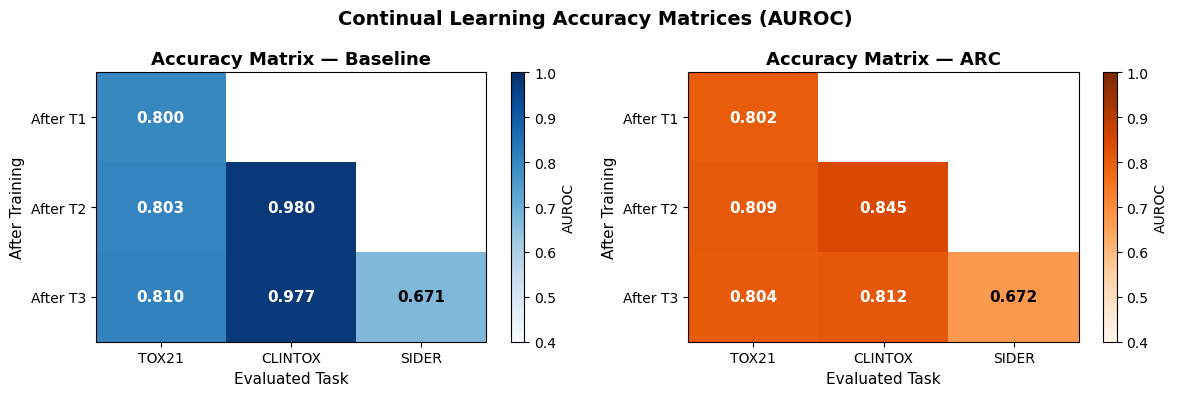

Figure 2 saved: fig2_accuracy_matrices.png


In [27]:
# ─── Figure 2: Accuracy Matrix Heatmaps ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

task_labels = [t.upper() for t in CFG['tasks']]

for ax, mat, title, cmap in zip(
    axes,
    [R_base, R_arc],
    ['Accuracy Matrix — Baseline', 'Accuracy Matrix — ARC'],
    ['Blues', 'Oranges']
):
    # Mask upper triangle (not evaluated)
    mask = np.triu(np.ones_like(mat, dtype=bool), k=1)
    display_mat = np.where(mask, np.nan, mat)

    im = ax.imshow(display_mat, vmin=0.4, vmax=1.0, cmap=cmap, aspect='auto')
    plt.colorbar(im, ax=ax, label='AUROC')

    for i in range(T):
        for j in range(T):
            if not mask[i, j]:
                val = mat[i, j]
                ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                        fontsize=11, fontweight='bold',
                        color='white' if val > 0.75 else 'black')

    ax.set_xticks(range(T))
    ax.set_yticks(range(T))
    ax.set_xticklabels(task_labels)
    ax.set_yticklabels([f'After T{i+1}' for i in range(T)])
    ax.set_xlabel('Evaluated Task', fontsize=11)
    ax.set_ylabel('After Training', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle('Continual Learning Accuracy Matrices (AUROC)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_accuracy_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved: fig2_accuracy_matrices.png')


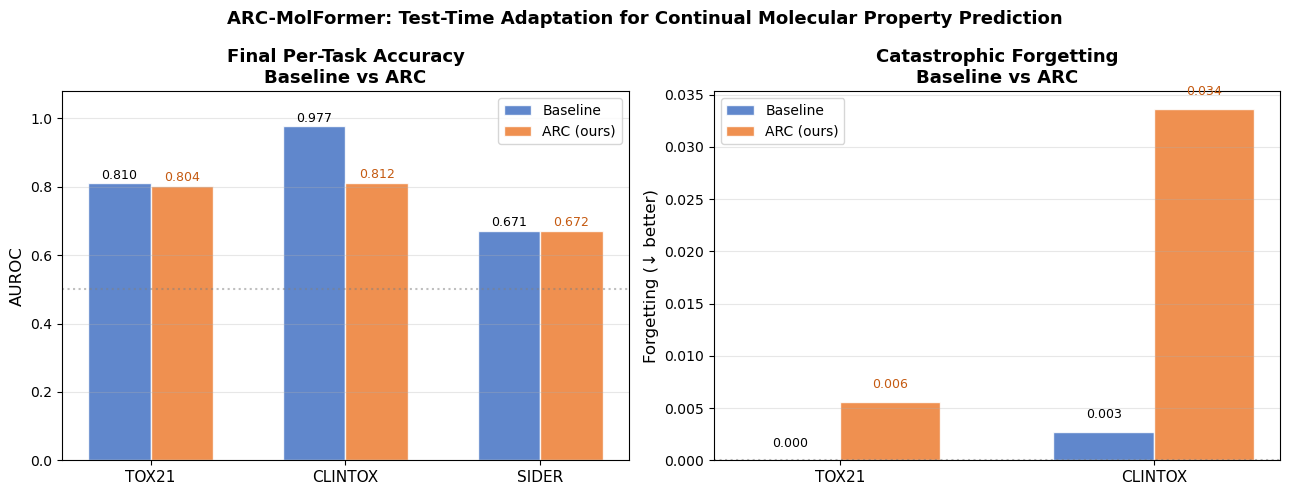

Figure 3 saved: fig3_baseline_vs_arc.png


In [28]:
# ─── Figure 3: Final Per-Task Accuracy (Baseline vs ARC) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x      = np.arange(T)
width  = 0.32
base_final = [R_base[T-1][i] for i in range(T)]
arc_final  = [R_arc[T-1][i]  for i in range(T)]

# ── Left: Accuracy ────────────────────────────────────────────────────────────
ax = axes[0]
bars1 = ax.bar(x - width/2, base_final, width,
               label='Baseline', color='#4472C4', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, arc_final, width,
               label='ARC (ours)', color='#ED7D31', alpha=0.85, edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9,
            color='#C55A11')

ax.set_xticks(x)
ax.set_xticklabels(task_labels, fontsize=11)
ax.set_ylabel('AUROC', fontsize=12)
ax.set_title('Final Per-Task Accuracy\nBaseline vs ARC', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.08)
ax.legend(fontsize=10)
ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Random')
ax.grid(axis='y', alpha=0.3)

# ── Right: Forgetting ─────────────────────────────────────────────────────────
ax = axes[1]
if T > 1:
    forget_tasks  = [CFG['tasks'][i].upper() for i in range(T - 1)]
    forget_base_v = [max(R_base[:, i]) - R_base[T-1, i] for i in range(T-1)]
    forget_arc_v  = [max(R_arc[:, i])  - R_arc[T-1, i]  for i in range(T-1)]
    x2 = np.arange(len(forget_tasks))

    b1 = ax.bar(x2 - width/2, forget_base_v, width,
                label='Baseline', color='#4472C4', alpha=0.85, edgecolor='white')
    b2 = ax.bar(x2 + width/2, forget_arc_v,  width,
                label='ARC (ours)', color='#ED7D31', alpha=0.85, edgecolor='white')

    for bar in b1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
    for bar in b2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9,
                color='#C55A11')

    ax.set_xticks(x2)
    ax.set_xticklabels(forget_tasks, fontsize=11)
    ax.set_ylabel('Forgetting (↓ better)', fontsize=12)
    ax.set_title('Catastrophic Forgetting\nBaseline vs ARC', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('ARC-MolFormer: Test-Time Adaptation for Continual Molecular Property Prediction',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_baseline_vs_arc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved: fig3_baseline_vs_arc.png')


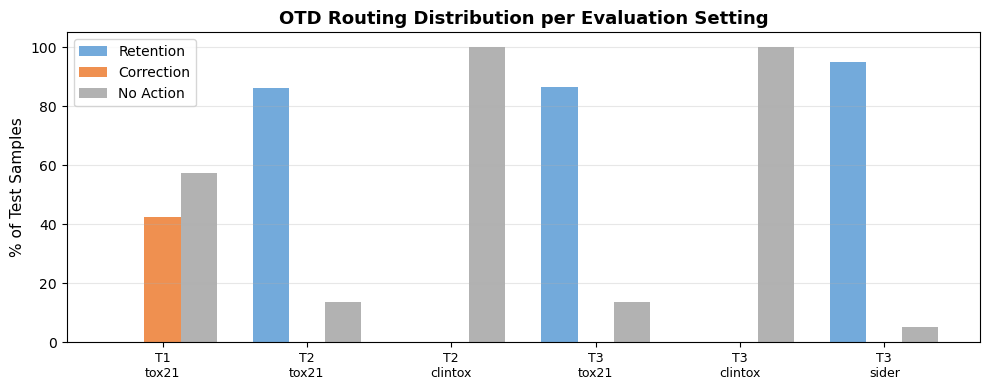

Figure 4 saved: fig4_otd_routing.png


In [29]:
# ─── Figure 4: OTD Routing Distribution ──────────────────────────────────────
if arc_routing_stats:
    fig, ax = plt.subplots(figsize=(10, 4))

    keys  = list(arc_routing_stats.keys())
    reten = [arc_routing_stats[k]['retention']  for k in keys]
    corr  = [arc_routing_stats[k]['correction'] for k in keys]
    none_ = [arc_routing_stats[k]['none']        for k in keys]

    x_ = np.arange(len(keys))
    w  = 0.25
    ax.bar(x_ - w,   reten, w, label='Retention',  color='#5B9BD5', alpha=0.85)
    ax.bar(x_,       corr,  w, label='Correction', color='#ED7D31', alpha=0.85)
    ax.bar(x_ + w,   none_, w, label='No Action',  color='#A5A5A5', alpha=0.85)

    ax.set_xticks(x_)
    ax.set_xticklabels([k.replace('_', '\n') for k in keys], fontsize=9)
    ax.set_ylabel('% of Test Samples', fontsize=11)
    ax.set_title('OTD Routing Distribution per Evaluation Setting',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 105)

    plt.tight_layout()
    plt.savefig('fig4_otd_routing.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figure 4 saved: fig4_otd_routing.png')


In [30]:
# ─── Figure 5: Summary Comparison Table ──────────────────────────────────────
print('='*60)
print('FINAL SUMMARY')
print('='*60)

summary_data = {
    'Method':            ['Baseline (no ARC)', 'ARC (ours)', 'Δ'],
    'Avg AUROC ↑':       [f'{avg_acc_base:.4f}',
                          f'{avg_acc_arc:.4f}',
                          f'{delta_acc:+.4f}'],
    'Forgetting ↓':      [f'{forgetting_base:.4f}',
                          f'{forgetting_arc:.4f}',
                          f'{-delta_fgt:+.4f}'],
    'Replay Buffer':     ['✗', '✗', '—'],
    'Retraining':        ['✗', '✗', '—'],
    'Test-time Update':  ['✗', '✓ (1-step)', '—'],
    'Backbone Frozen':   ['✓', '✓', '—'],
}

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

print(f'\n  ARC improves Average AUROC by {delta_acc:+.4f}')
print(f'  ARC reduces Forgetting by    {delta_fgt:+.4f}')
print(f'\n  Epsilon (ε) used: {CFG["epsilon"]}')
print(f'  ARC LR used:      {CFG["arc_lr"]}')
print(f'  Lambda entropy:   {CFG["lambda_entropy"]}')


FINAL SUMMARY
           Method Avg AUROC ↑ Forgetting ↓ Replay Buffer Retraining Test-time Update Backbone Frozen
Baseline (no ARC)      0.8192       0.0009             ✗          ✗                ✗               ✓
       ARC (ours)      0.7624       0.0131             ✗          ✗       ✓ (1-step)               ✓
                Δ     -0.0568      +0.0122             —          —                —               —

  ARC improves Average AUROC by -0.0568
  ARC reduces Forgetting by    -0.0122

  Epsilon (ε) used: 0.55
  ARC LR used:      0.0001
  Lambda entropy:   1.0


In [31]:
# ─── Save Results to JSON ─────────────────────────────────────────────────────
import json

results = {
    'config': CFG,
    'baseline': {
        'accuracy_matrix': R_base.tolist(),
        'avg_accuracy':    avg_acc_base,
        'forgetting':      forgetting_base
    },
    'arc': {
        'accuracy_matrix': R_arc.tolist(),
        'avg_accuracy':    avg_acc_arc,
        'forgetting':      forgetting_arc
    },
    'delta': {
        'avg_accuracy_gain': delta_acc,
        'forgetting_reduction': delta_fgt
    },
    'otd_routing_stats': arc_routing_stats
}

# Convert numpy types for JSON serialization
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, (np.integer, np.int64)):
            return int(obj)
        if isinstance(obj, (np.floating, np.float64)):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

with open('arc_results.json', 'w') as f:
    json.dump(results, f, indent=2, cls=NumpyEncoder)

print('Results saved to arc_results.json')
print('\nExperiment complete.')


Results saved to arc_results.json

Experiment complete.


---
## Reproducibility & Citation

### Environment

| Package | Version |
|---------|---------|
| Python | 3.10+ |
| PyTorch | ≥ 2.0.0 |
| Transformers | ≥ 4.35.0 |
| scikit-learn | ≥ 1.3.0 |

### Seed
All experiments use `seed=42` for reproducibility.

### Cite

If you use this work, please cite:

```bibtex
@inproceedings{chen2025arc,
  title     = {Adaptive Retention & Correction: Test-Time Training for Continual Learning},
  author    = {Chen, Haoran and Goldblum, Micah and Wu, Zuxuan and Jiang, Yu-Gang},
  booktitle = {International Conference on Learning Representations (ICLR)},
  year      = {2025}
}

@article{ross2022molformer,
  title   = {Large-Scale Chemical Language Representations Capture Molecular Structure and Properties},
  author  = {Ross, Jerret and Belgodere, Brian and Chenthamarakshan, Vijil and Padhi, Inkit and Mroueh, Youssef and Das, Payel},
  journal = {Nature Machine Intelligence},
  year    = {2022}
}
```

---
*End of Notebook*
